**Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


**Load Dataset**

In [3]:
file_path = "/content/drive/MyDrive/c01-price-forecasting/data/processed/cleaned_data.csv"
df = pd.read_csv(file_path)

print("Dataset loaded")
print("Shape:", df.shape)

display(df.head())

Dataset loaded
Shape: (2308, 30)


,date,district,paddy_type,min_price,max_price,avg_price,production_total,price_range,week_of_year,week_sin,...,year,month,week,lag_1,lag_2,lag_4,lag_12,rolling_mean_4,rolling_std_4,season_Yala
0,2015-03-26,Ampara,Long_Grain_White,34.0,40.0,37.14,307661,6.0,13,1.000000,...,2015,3,13,37.48,38.50,36.34,27.50,37.6575,0.586195,False
1,2015-04-02,Ampara,Long_Grain_White,34.0,40.0,36.40,309335,6.0,14,0.992709,...,2015,4,14,37.14,37.48,37.51,26.10,37.3800,0.872238,True
2,2015-04-09,Ampara,Long_Grain_White,34.0,39.0,35.68,309335,5.0,15,0.970942,...,2015,4,15,36.40,37.14,38.50,26.58,36.6750,0.802060,True
3,2015-04-16,Ampara,Long_Grain_White,31.0,37.0,34.97,309335,6.0,16,0.935016,...,2015,4,16,35.68,36.40,37.48,28.95,36.0475,0.933430,True
4,2015-04-23,Ampara,Long_Grain_White,30.0,38.0,34.03,309335,8.0,17,0.885456,...,2015,4,17,34.97,35.68,37.14,30.64,35.2700,1.012028,True


**Basic Info**

In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

Columns:
['date', 'district', 'paddy_type', 'min_price', 'max_price', 'avg_price', 'production_total', 'price_range', 'week_of_year', 'week_sin', 'week_cos', 'price_t-1', 'price_t-2', 'price_t-3', 'price_t-4', 'price_t-8', 'price_t-12', 'price_4w_avg', 'price_8w_avg', 'price_change', 'year', 'month', 'week', 'lag_1', 'lag_2', 'lag_4', 'lag_12', 'rolling_mean_4', 'rolling_std_4', 'season_Yala']

Missing values:
date                0
district            0
paddy_type          0
min_price           0
max_price           0
avg_price           0
production_total    0
price_range         0
week_of_year        0
week_sin            0
week_cos            0
price_t-1           0
price_t-2           0
price_t-3           0
price_t-4           0
price_t-8           0
price_t-12          0
price_4w_avg        0
price_8w_avg        0
price_change        0
year                0
month               0
week                0
lag_1               0
lag_2               0
lag_4               0
lag_12        

**Price Trend**

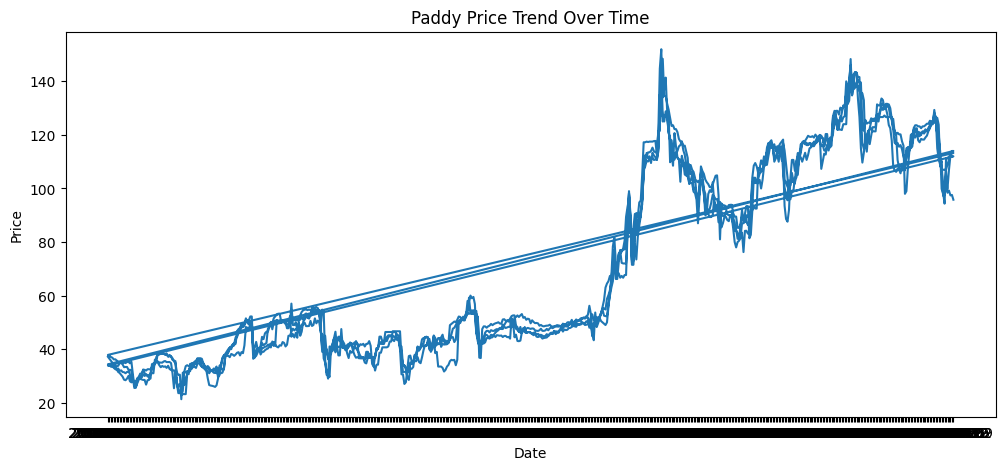

In [5]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['avg_price'])
plt.title("Paddy Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

The price trend shows fluctuations over time, indicating seasonal and market-driven variations in paddy prices.

**Season Comparison**

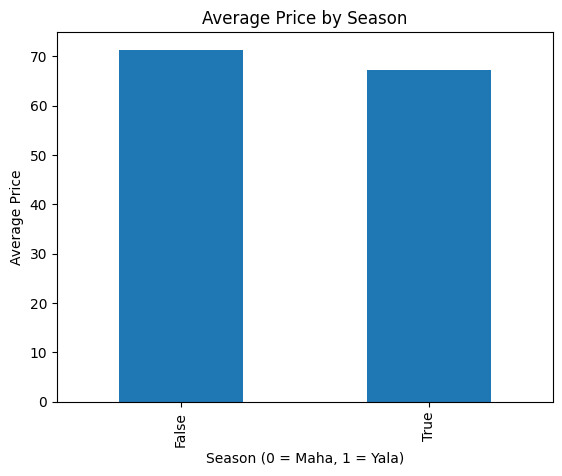

In [6]:
df.groupby('season_Yala')['avg_price'].mean().plot(kind='bar')

plt.title("Average Price by Season")
plt.xlabel("Season (0 = Maha, 1 = Yala)")
plt.ylabel("Average Price")
plt.show()

The Maha season shows relatively lower prices due to higher production, while the Yala season tends to have higher prices due to reduced supply.

**District Price Comparison**

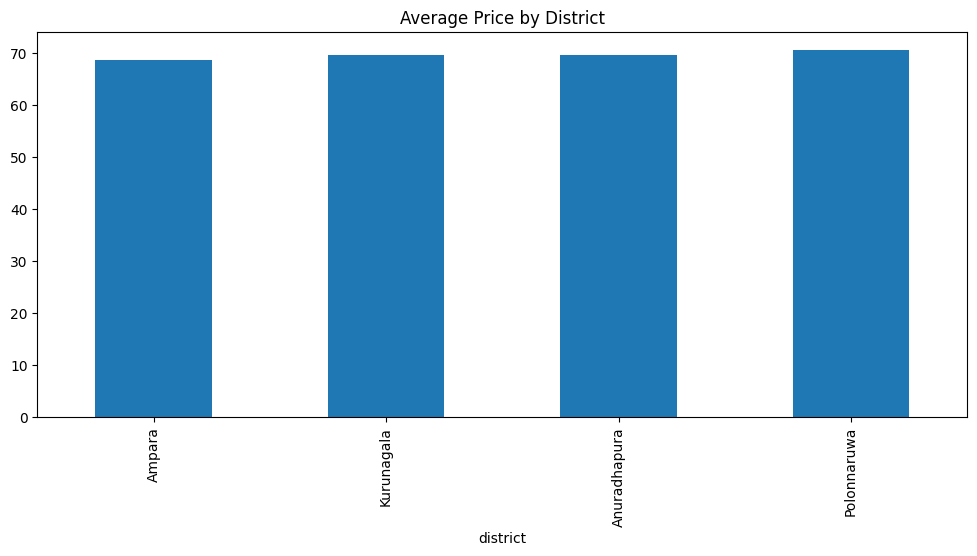

In [7]:
if 'district' in df.columns:
    df.groupby('district')['avg_price'].mean().sort_values().plot(kind='bar', figsize=(12,5))
    plt.title("Average Price by District")
    plt.show()
else:
    print("District column not found")

Price variations across districts indicate regional differences in production, demand, and supply chain factors.

**Lag Correlation**

In [8]:
lag_corr = df[['avg_price','lag_1','lag_2','lag_4','lag_12']].corr()

print(lag_corr)

           avg_price     lag_1     lag_2     lag_4    lag_12
avg_price   1.000000  0.995340  0.989977  0.980759  0.950130
lag_1       0.995340  1.000000  0.995337  0.985260  0.954181
lag_2       0.989977  0.995337  1.000000  0.989971  0.957762
lag_4       0.980759  0.985260  0.989971  1.000000  0.964130
lag_12      0.950130  0.954181  0.957762  0.964130  1.000000


Strong correlation between current price and lag features confirms that past prices significantly influence future prices.

**Heatmap**

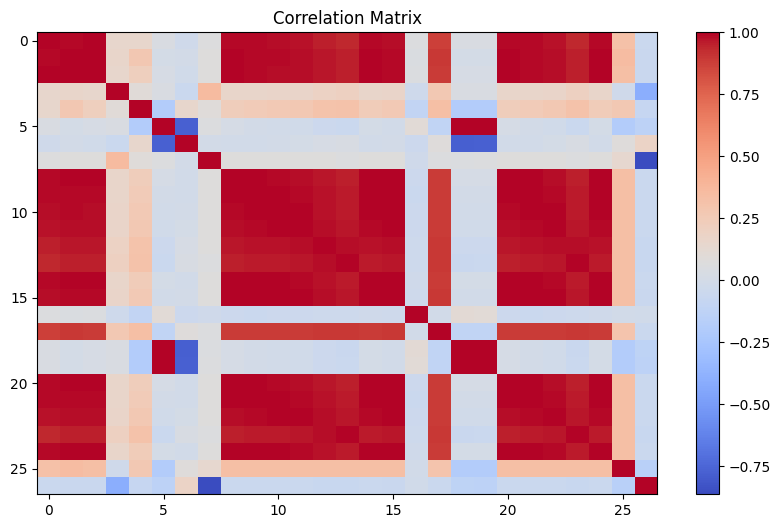

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

The correlation matrix highlights relationships between features and helps identify important predictors for forecasting models.

**Histogram**

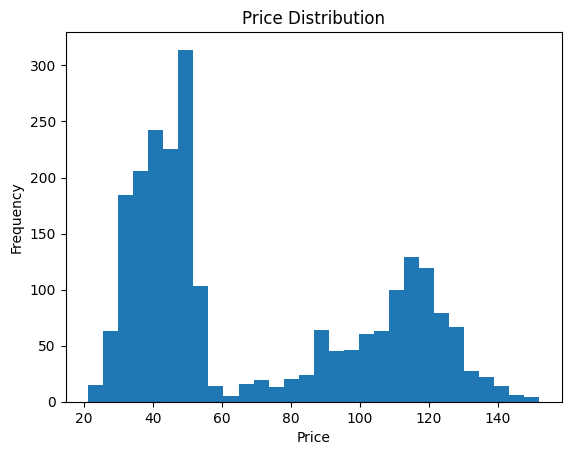

In [10]:
plt.hist(df['avg_price'], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

The distribution shows how price values are spread and helps identify skewness or irregular patterns.

**Boxplot**

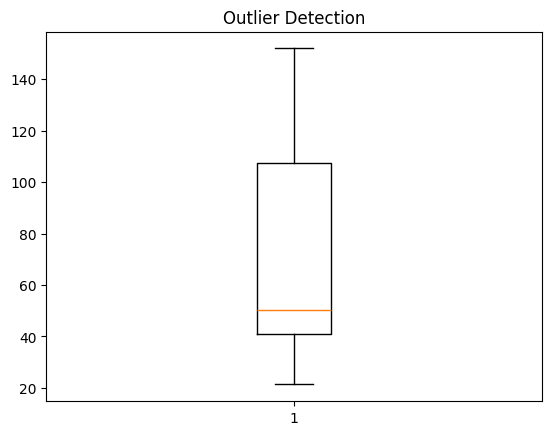

In [11]:
plt.boxplot(df['avg_price'])
plt.title("Outlier Detection")
plt.show()

Outliers represent unusual market conditions or anomalies that may affect model performance.